In [1]:
from itertools import cycle
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from STiMetaD import STiMetaD
import numpy as np
import pickle
from common.consts import groupByResidue, groupByProperty, mutation_map, proteins, thresholds
from common.utils import estimateMFPT

thresholds = np.arange(0.2, 0.50, 0.04)
short_to_residue = {short: idx for idx, shorts in groupByResidue.items() for short in shorts}
short_to_property = {short: prop for prop, shorts in groupByProperty.items() for short in shorts}

top5_evec_dot = pd.read_csv('../data/top5_evec_dot.csv', index_col='Mutant')
eigenvalue_data = pd.read_csv('../data/eigenvalues.csv', index_col='mutation')
full_evec_dot = pd.read_csv('../data/full_evec_dot.csv', index_col='Mutant')
avg_change_diff = pd.read_csv('../data/average_change_difference.csv', index_col='Mutant')
avg_change_folded = pd.read_csv('../data/average_change_folded.csv', index_col='Mutant')
avg_change_unfolded = pd.read_csv('../data/average_change_unfolded.csv', index_col='Mutant')
cov_dot_product = pd.read_csv('../data/cov_dot_products.csv', index_col='Mutant')
diagonal_cov_dot_products = pd.read_csv('../data/diagonal_cov_dot_products.csv', index_col='Mutant')
variance_differences = pd.read_csv('../data/variance_differences.csv', index_col='Mutant')


def collect_df(all_mfpt, th: float, sample_size: int):
    rows = []

    for long_name in proteins:
        short = mutation_map.get(long_name)
        if short is None:
            raise ValueError(f"Unknown mutation: {long_name}")
        s = np.sort(np.array(all_mfpt[long_name][th]))
        mfpt, lim = estimateMFPT(s, 10)
        print(f"{long_name} ({short}): {(mfpt * 1e-6):.4g} us, extra: {lim:.4g}")

        rows.append({
            "long": long_name,
            "short": short,
            "eigenvalue": eigenvalue_data.loc[short, "eigenvalue"],
            "mfpt": mfpt,
            "lim": lim,
            "full_evec_dot": full_evec_dot['full_evec_dot'].get(short, None),
            "cos_sim_folded": cov_dot_product['CosSim_Folded'].get(short, None),
            "cos_sim_unfolded": cov_dot_product['CosSim_Unfolded'].get(short, None),
            "avg_change_diff": avg_change_diff['AvgChange_Diff_F-U'].get(short, None),
            "diagonal_cov_dot_folded": diagonal_cov_dot_products['Diagonal_Dot_Folded'].get(short, None),
            "diagonal_cov_dot_unfolded": diagonal_cov_dot_products['Diagonal_Dot_Unfolded'].get(short, None),
            "abs_dvar_folded": variance_differences['abs_dvar_F'].get(short, None),
            "avg_change_folded": avg_change_folded['AvgChange_Folded'].get(short, None),
            "avg_change_unfolded": avg_change_unfolded['AvgChange_Unfolded'].get(short, None),
            "abs_dvar_unfolded": variance_differences['abs_dvar_U'].get(short, None),
            "top5_evec_dot": top5_evec_dot['top5_evec_dot'].get(short, None),
            "residue_idx": short_to_residue.get(short),
            "property_grp": short_to_property.get(short),
        })

    df = pd.DataFrame(rows)
    df.set_index("short", inplace=True)
    return df


/rg/mendels_prj/alexander.z/protein-toolkit/src/common/utils.py:45: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(1 / max.prediction), int(limit)
/rg/mendels_prj/alexander.z/protein-toolkit/src/common/utils.py:45: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  return float(1 / max.prediction), int(limit)


chignolin (Wildtype): 18.2 us, extra: 14
YYCPETGTWY (D2C): 12.18 us, extra: 13
YYDPETGTWE (Y9E): 1.599 us, extra: 14
YYRPETGTWY (D2R): 31.12 us, extra: 12
YYAPETGTWY (D2A): 23.98 us, extra: 14
YYDPETGQWY (T7Q): 74.81 us, extra: 10
YYDPETGTWG (Y9G): 1.13 us, extra: 28
YYDPETGTWQ (Y9Q): 2.597 us, extra: 17
YYNPETGTWY (D2N): 1.302 us, extra: 12
YYEPETGTWY (D2E): 48.75 us, extra: 23
YYDPETGTWR (Y9R): 20.42 us, extra: 23
YYDPETGVWY (T7V): 37.18 us, extra: 15
YYDPETGYWY (T7Y): 19.44 us, extra: 19
YYDPETGTWV (Y9V): 0.8676 us, extra: 12
YYDPETGRWY (T7R): 557 us, extra: 17


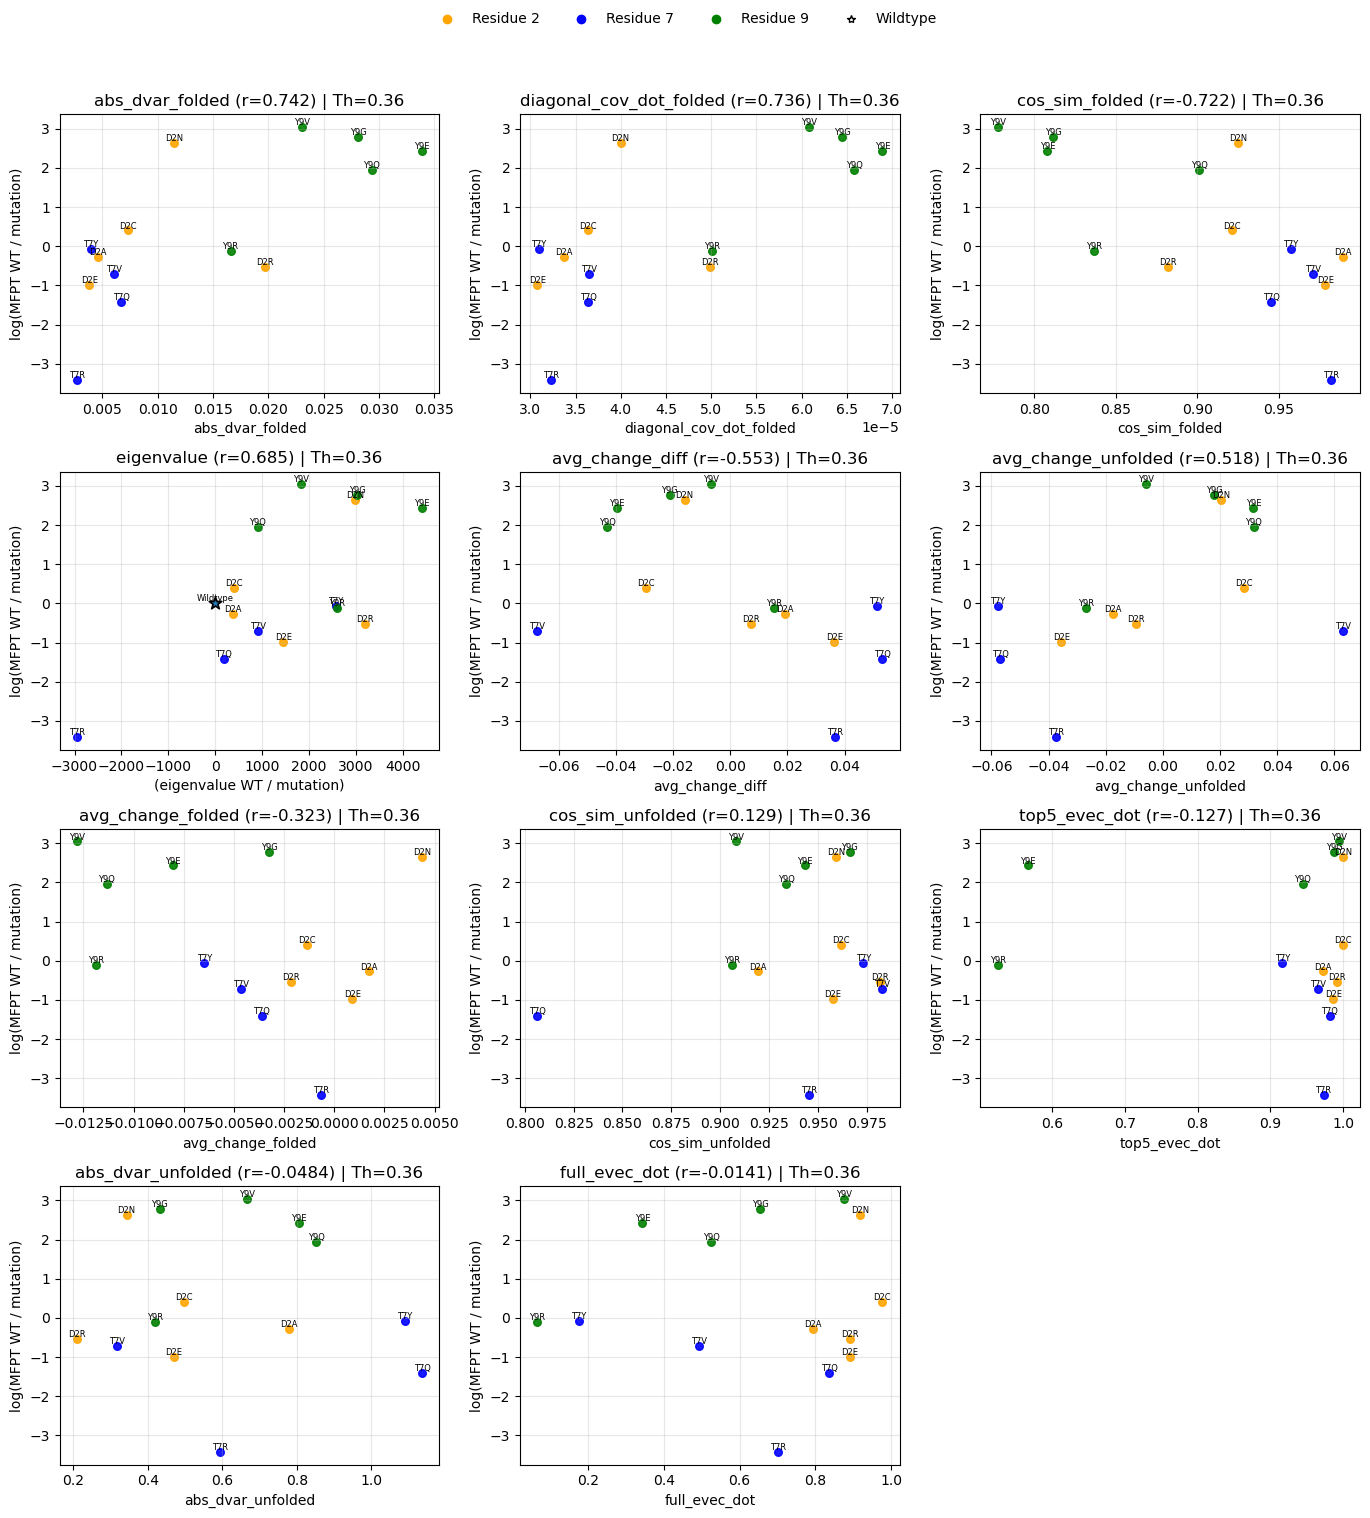

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import stats
import pickle

def _ratio_or_raw(wt, arr, use_log, colname):
    if pd.isna(wt):
        return arr
    return wt - arr

def plot_mfpt_corr_grid(
    df: pd.DataFrame,
    prop_cols,
    wt_label='Wildtype',
    group_col='residue_idx',
    annotate=True,
    th=None,
    log_prop=True,
    ncols=3
):
    res_keys = sorted(int(k) for k in df[group_col].dropna().unique())
    base_colors = plt.rcParams['axes.prop_cycle'].by_key().get('color', [])
    res_colors = {k: base_colors[i % len(base_colors)] for i, k in enumerate(res_keys)}
    res_colors[2] = 'orange'
    res_colors[7] = 'blue'
    res_colors[9] = 'green'
    pearson_spearman = {}
    wt_mfpt = float(df.loc[wt_label, 'mfpt'])
    wt_star = dict(s=90, marker='*', edgecolors='k', linewidths=1.2, zorder=3)

    for prop_col in prop_cols:
        wt_prop = df.loc[wt_label, prop_col]
        x_all = df[prop_col].to_numpy() if wt_prop == None else _ratio_or_raw(wt_prop, df[prop_col].to_numpy(), log_prop, prop_col)
        y_all = np.log(wt_mfpt / df['mfpt'].to_numpy())
        mask = np.isfinite(x_all) & np.isfinite(y_all)
        pearson, _ = stats.pearsonr(x_all[mask], y_all[mask]) if mask.any() else (np.nan, None)
        pearson_spearman[prop_col] = pearson

    ordered_props = sorted(prop_cols, key=lambda p: abs(pearson_spearman[p]), reverse=True)
    n = len(ordered_props)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 3.8 * nrows), squeeze=False)

    for idx, prop_col in enumerate(ordered_props):
        ax = axes[idx // ncols][idx % ncols]
        wt_prop = df.loc[wt_label, prop_col]
        x_all = _ratio_or_raw(wt_prop, df[prop_col].to_numpy(), log_prop, prop_col)
        y_all = np.log(wt_mfpt / df['mfpt'].to_numpy())
        mask = np.isfinite(x_all) & np.isfinite(y_all)
        for k in res_keys:
            sub = df[df[group_col] == k]
            if sub.empty:
                continue
            x = _ratio_or_raw(wt_prop, sub[prop_col].to_numpy(), log_prop, prop_col)
            y = np.log(wt_mfpt / sub['mfpt'].to_numpy())
            ax.scatter(x, y, s=30, alpha=0.9, c=res_colors.get(k))
        if not pd.isna(wt_prop):
            ax.scatter(0 if log_prop else wt_prop, 0, **wt_star)
        if annotate:
            names = df.index.to_numpy()
            for xv, yv, name, m in zip(x_all, y_all, names, mask):
                if m:
                    ax.text(xv, yv, name, fontsize=6, ha='center', va='bottom')
        pearson = pearson_spearman[prop_col]
        xlabel = (f'({prop_col} WT / mutation)' if log_prop and not pd.isna(wt_prop) else prop_col)
        ax.set_xlabel(xlabel)
        ax.set_ylabel('log(MFPT WT / mutation)')
        suffix = f" | Th={th:.3g}" if th is not None else ""
        ax.set_title(f"{prop_col} (r={pearson:.3g}){suffix}")
        ax.grid(True, alpha=0.3)

    for j in range(n, nrows * ncols):
        fig.delaxes(axes[j // ncols][j % ncols])

    handles = [Line2D([0], [0], marker='o', linestyle='',
                      color=res_colors[k], label=f"Residue {k}") for k in res_keys]
    handles.append(Line2D([0], [0], marker='*', linestyle='', color='w',
                          markeredgecolor='k', label=wt_label))
    fig.legend(handles=handles, loc='upper center', ncol=min(len(handles), 6), frameon=False)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    return pearson_spearman

props = [
    'cos_sim_unfolded', 'cos_sim_folded', 
    'eigenvalue', 'full_evec_dot', 'avg_change_diff', 'avg_change_folded',
    'avg_change_unfolded', 
    'diagonal_cov_dot_folded', 'abs_dvar_folded', 'abs_dvar_unfolded',
    'top5_evec_dot',
]

with open("../data/mfpt-pace=25000.pkl", "rb") as f:
    all_mfpt = pickle.load(f)
sample_size = 200
th = thresholds[4]

df = collect_df(all_mfpt, th, sample_size)

stats_map = plot_mfpt_corr_grid(df, props, annotate=True, th=th, log_prop=True, ncols=3)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def parse_short(s):
    return s[0], s[-1]

def compute_mfpt(long_name, th):
    s = np.sort(np.array(all_mfpt[long_name][th], float))
    mfpt, _ = estimateMFPT(s, 10)
    return float(mfpt)

def gather(proteins, mutation_map, th):
    xb, xg, y, labels = [], [], [], []
    wt_mfpt = compute_mfpt('chignolin', th)
    for long_name in proteins:
        short = mutation_map.get(long_name)
        if not short:
            continue
        a, b = parse_short(short)
        if (a, b) not in blosum62 or (a, b) not in grantham:
            continue
        mfpt = compute_mfpt(long_name, th)
        if not np.isfinite(mfpt) or mfpt <= 0:
            continue
        xb.append(float(blosum62[(a, b)]))
        xg.append(float(grantham[(a, b)]))
        y.append(np.log(wt_mfpt / mfpt))
        labels.append(short)
    return np.array(xb), np.array(xg), np.array(y), labels

def scatter_fit(ax, x, y, labels, title, xlabel):
    ax.scatter(x, y)
    for xi, yi, lab in zip(x, y, labels):
        ax.text(xi, yi, lab, fontsize=8, ha="right", va="bottom")

    if len(x) >= 2:
        r, p = stats.pearsonr(x, y)
        ax.set_title(f"{title}\nr={r:.2f}, p={p:.2g}")
    else:
        ax.set_title(title)

    ax.set_xlabel(xlabel)
    ax.set_ylabel("log(MFPT(WT / Mut))")

def plot_correlations_over(proteins, mutation_map, th):
    xb, xg, y, labels = gather(proteins, mutation_map, th)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    scatter_fit(axes[0], xb, y, labels, "BLOSUM62 vs log(MFPT)", "BLOSUM62 (orig→mut)")
    scatter_fit(axes[1], xg, y, labels, "Grantham vs log(MFPT)", "Grantham distance (orig→mut)")
    plt.tight_layout()
    plt.show()
    return {"labels": labels, "blosum": xb, "grantham": xg, "log_mfpt": y}

# Example usage
th = thresholds[5]
res = plot_correlations_over(proteins[:-1], mutation_map, th)


NameError: name 'blosum62' is not defined

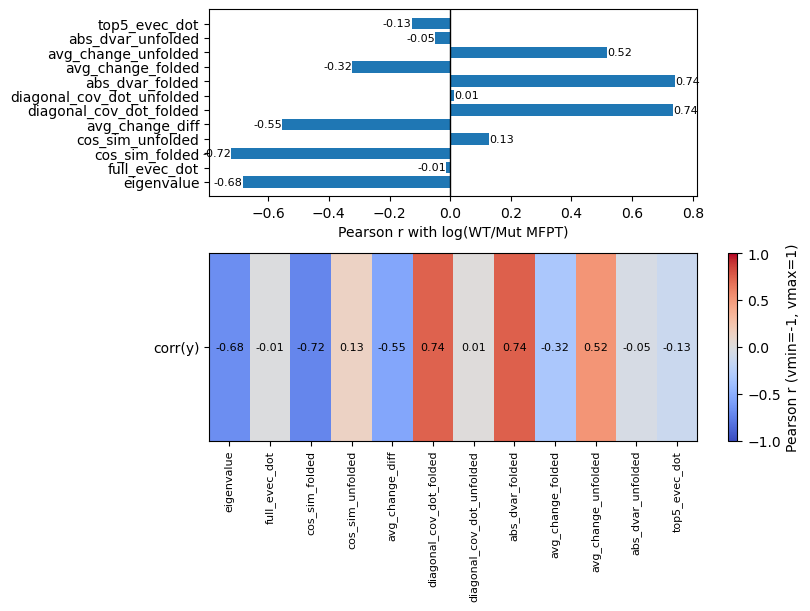

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def corr_vector(df, features, target_log_ratio=True):
    wt_mfpt = float(df.loc['Wildtype','mfpt'])
    y = np.log(wt_mfpt / df['mfpt'].to_numpy()) if target_log_ratio else df['mfpt'].to_numpy()
    cors = []
    for f in features:
        x = df[f].to_numpy(dtype=float)
        m = np.isfinite(x) & np.isfinite(y)
        if m.sum() >= 3 and np.std(x[m]) > 1e-12 and np.std(y[m]) > 1e-12:
            r, _ = stats.pearsonr(x[m], y[m])
        else:
            r = np.nan
        cors.append(r)
    return np.array(cors, float)

def plot_corr_bar_and_heatmap(df, features):
    cors = corr_vector(df, features, target_log_ratio=True)

    fig, axes = plt.subplots(2, 1, figsize=(max(8, 0.6*len(features)), 6), constrained_layout=True)

    ax = axes[0]
    ax.barh(features, np.nan_to_num(cors, nan=0.0))
    ax.axvline(0, lw=1, color='k')
    ax.set_xlabel("Pearson r with log(WT/Mut MFPT)")
    for i, r in enumerate(cors):
        if np.isfinite(r):
            ax.text(r, i, f"{r:.2f}", va='center', ha='left' if r>=0 else 'right', fontsize=8)

    ax = axes[1]
    H = np.nan_to_num(cors, nan=0.0)[None, :]
    im = ax.imshow(H, aspect='auto', vmin=-1, vmax=1, cmap='coolwarm')
    ax.set_yticks([0])
    ax.set_yticklabels(["corr(y)"])
    ax.set_xticks(np.arange(len(features)))
    ax.set_xticklabels(features, rotation=90, fontsize=8)
    for j, r in enumerate(cors):
        txt = "NA" if not np.isfinite(r) else f"{r:.2f}"
        ax.text(j, 0, txt, ha='center', va='center', fontsize=8, color='black')
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Pearson r (vmin=-1, vmax=1)")

    plt.show()

# Example:
features = ["eigenvalue","full_evec_dot","cos_sim_folded","cos_sim_unfolded",
            "avg_change_diff","diagonal_cov_dot_folded","diagonal_cov_dot_unfolded",
            "abs_dvar_folded","avg_change_folded","avg_change_unfolded",
            "abs_dvar_unfolded","top5_evec_dot"]
plot_corr_bar_and_heatmap(df, features)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.metrics import mutual_info_score
from pgmpy.estimators import HillClimbSearch
from pgmpy.models import DiscreteBayesianNetwork

def _bin_series(s, n_bins):
    s = pd.Series(s).astype(float)
    if s.nunique() <= 1:
        return pd.Series(["bin1"] * len(s), index=s.index)
    try:
        return pd.qcut(s, q=n_bins, labels=[f"q{i+1}" for i in range(n_bins)], duplicates="drop")
    except Exception:
        cats = pd.cut(s, bins=n_bins, labels=[f"b{i+1}" for i in range(n_bins)], duplicates="drop", include_lowest=True)
        cats = cats.astype(str).str.replace(r"\(|\)|\[|\]", "", regex=True)
        return cats

def discretize_df(df, cols, n_bins=3):
    out = df.copy()
    for c in cols:
        out[c] = _bin_series(out[c], n_bins)
    return out

def learn_discrete_bn(df, n_bins=3, draw=True):
    wt_mfpt = float(df.loc["Wildtype", "mfpt"])
    dfb = df.copy()
    if "Wildtype" in dfb.index:
        dfb = dfb.drop("Wildtype")

    features = [
        "eigenvalue","full_evec_dot","cos_sim_folded","cos_sim_unfolded",
        "avg_change_diff","diagonal_cov_dot_folded","diagonal_cov_dot_unfolded",
        "abs_dvar_folded","avg_change_folded","avg_change_unfolded",
        "abs_dvar_unfolded","top5_evec_dot", "mfpt"
    ]
    dfb = dfb[features].dropna()

    disc_cols = discretize_df(dfb, features, n_bins=n_bins)
    use_cols = features
    d = disc_cols[use_cols].astype("category")

    est = HillClimbSearch(d)
    best = est.estimate(scoring_method="bic-d")
    model = DiscreteBayesianNetwork(best.edges())
    model.fit(d)

    if draw:
        G = nx.DiGraph(model.edges())
        plt.figure(figsize=(9, 7))
        pos = nx.shell_layout(G)
        nx.draw(G, pos, with_labels=True, node_color="#cfe8ff", node_size=2200, font_size=9, arrowsize=18)
        plt.title("BN")
        plt.tight_layout()
        plt.show()

    target = "mfpt"
    parents = model.get_parents(target) if target in d.columns else []
    print("Edges:")
    for u, v in model.edges():
        print(f"{u} -> {v}")
    print("\nParents of mfpt:", parents)

    mi = {}
    if target in d.columns:
        y = d[target].astype(str).to_numpy()
        for c in d.columns:
            if c == target: 
                continue
            x = d[c].astype(str).to_numpy()
            m = pd.notna(x) & pd.notna(y)
            mi[c] = mutual_info_score(x[m], y[m]) if m.sum() >= 3 else np.nan
        mi_sorted = sorted(mi.items(), key=lambda kv: (-(kv[1] if np.isfinite(kv[1]) else -np.inf)))
        print("\nMutual information with log_mfpt:")
        for k, v in mi_sorted:
            print(f"{k:30s} {v:.4f}" if np.isfinite(v) else f"{k:30s} NA")

        plt.figure(figsize=(max(8, 0.6*len(mi_sorted)), 4))
        xs = [k for k,_ in mi_sorted]
        ys = [0.0 if not np.isfinite(v) else v for _,v in mi_sorted]
        plt.bar(xs, ys)
        plt.xticks(rotation=75, ha='right', fontsize=9)
        plt.ylabel("Mutual information with log_mfpt")
        plt.tight_layout()
        plt.show()

    return model

# usage:
bn_model = learn_discrete_bn(df, n_bins=3, draw=True)


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'eigenvalue': 'C', 'full_evec_dot': 'C', 'cos_sim_folded': 'C', 'cos_sim_unfolded': 'C', 'avg_change_diff': 'C', 'diagonal_cov_dot_folded': 'C', 'diagonal_cov_dot_unfolded': 'C', 'abs_dvar_folded': 'C', 'avg_change_folded': 'C', 'avg_change_unfolded': 'C', 'abs_dvar_unfolded': 'C', 'top5_evec_dot': 'C', 'mfpt': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'eigenvalue': 'C', 'full_evec_dot': 'C', 'cos_sim_folded': 'C', 'cos_sim_unfolded': 'C', 'avg_change_diff': 'C', 'diagonal_cov_dot_folded': 'C', 'diagonal_cov_dot_unfolded': 'C', 'abs_dvar_folded': 'C', 'avg_change_folded': 'C', 'avg_change_unfolded': 'C', 'abs_dvar_unfolded': 'C', 'top5_evec_dot': 'C', 'mfpt': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'eigenvalue': 'C', 'full_evec_dot': 'C', 'cos_

  0%|          | 0/1000000 [00:00<?, ?it/s]

ValueError: endog has evaluated to an array with multiple columns that has shape (14, 14). This occurs when the variable converted to endog is non-numeric (e.g., bool or str).